# **IMPORT NECESSARY LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import files

# **LOAD DATASET**

In [2]:
df = pd.read_csv('cleaned_dataset_final.csv')

In [3]:
# Ensure 'Review' column is treated as string and 'Rating' as integer
df['Review'] = df['Review'].astype(str)
df['Rating'] = df['Rating'].astype(int)

In [4]:
df.dropna(subset=['Review', 'Rating'], inplace=True)
df.shape

(82071, 3)

# **PREPROCESSING**

In [5]:
# Drop reviews less than 3 words and more than 100 words

df['word_count'] = df['Review'].apply(lambda x: len(x.split()))

# Filter the DataFrame to keep reviews between 3 and 100 words (inclusive)
df_cleaned = df[(df['word_count'] >= 3) & (df['word_count'] <= 100)].copy()

print(f"Reviews dropped: {df.shape[0] - df_cleaned.shape[0]}")
print(f"Dataset shape after filtering: {df_cleaned.shape}")

Reviews dropped: 5425
Dataset shape after filtering: (76646, 4)


# **IMBALANCING DATASET (RANDOM RATIO)**

In [6]:
target_percentages = {
    1: 0.10,  # 10% of available Rating 1 reviews
    2: 0.50,  # 50% of available Rating 2 reviews
    3: 0.25,  # 25% of available Rating 3 reviews
    4: 0.15,  # 15% of available Rating 4 reviews
    5: 0.05   # 05% of available Rating 5 reviews
}

# Total available count per rating in the cleaned data
available_counts = df_cleaned['Rating'].value_counts().sort_index()
print("\nAvailable reviews per rating after cleaning (to check feasibility):\n")
print(available_counts)

# Determine the sample size for each rating
df_imbalanced_list = []
new_total_size = 0

print(f"\nImbalanced Dataset Creation\n")


for rating, percentage in target_percentages.items():

    if rating in available_counts:
        available_count = available_counts[rating]

        # Calculate target count using rounding to achieve the "proper percentage"
        # and then casting to integer for sampling.
        target_count_float = percentage * available_count
        target_count = int(round(target_count_float))

        # Ensure we don't try to sample more than is available (shouldn't happen here)
        n_sample = min(target_count, available_count)

        # Sample the calculated count
        sampled_df = df_cleaned[df_cleaned['Rating'] == rating].sample(n=n_sample, random_state=42)

        print(f"Rating {rating} (Target {int(percentage*100)}% of {available_count} available): "
              f"Calculated {target_count_float:.2f} reviews, Sampled {n_sample} reviews.")
    else:
        # No data for this rating
        sampled_df = pd.DataFrame()
        n_sample = 0
        print(f"Rating {rating}: No available reviews to sample.")

    df_imbalanced_list.append(sampled_df)
    new_total_size += n_sample

# Combine the sampled dataframes
df_imbalanced = pd.concat(df_imbalanced_list).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\nFinal Imbalanced Dataset Shape: {df_imbalanced.shape}")


Available reviews per rating after cleaning (to check feasibility):

Rating
1    11004
2     3315
3     6461
4    14568
5    41298
Name: count, dtype: int64

Imbalanced Dataset Creation

Rating 1 (Target 10% of 11004 available): Calculated 1100.40 reviews, Sampled 1100 reviews.
Rating 2 (Target 50% of 3315 available): Calculated 1657.50 reviews, Sampled 1658 reviews.
Rating 3 (Target 25% of 6461 available): Calculated 1615.25 reviews, Sampled 1615 reviews.
Rating 4 (Target 15% of 14568 available): Calculated 2185.20 reviews, Sampled 2185 reviews.
Rating 5 (Target 5% of 41298 available): Calculated 2064.90 reviews, Sampled 2065 reviews.

Final Imbalanced Dataset Shape: (8623, 4)


# **DATA VISUALIZATION**

### BAR PLOT

/tmp/ipython-input-2181923283.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=df_imbalanced, palette="viridis", edgecolor='black', zorder=3)


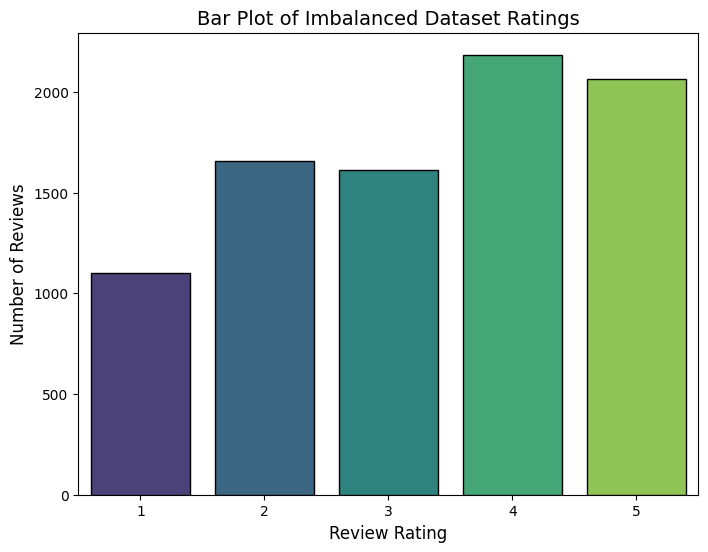

In [7]:
# Bar Plot
plt.figure(figsize=(8, 6))
sns.countplot(x='Rating', data=df_imbalanced, palette="viridis", edgecolor='black', zorder=3)
plt.title('Bar Plot of Imbalanced Dataset Ratings', fontsize=14)
plt.xlabel('Review Rating', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.show()

# **SAMPLE REVIEWS**

In [8]:
# Print 5 sample reviews from each rating

for rating in sorted(df_imbalanced['Rating'].unique()):
    samples = df_imbalanced[df_imbalanced['Rating'] == rating].head(5)
    print(f"\nRating {rating} Samples:")
    for i, row in samples.iterrows():
        # Truncate review for cleaner printing
        review_text = row['Review'][:300] + ('...' if len(row['Review']) > 300 else '')
        print(f"  - {review_text}")


Rating 1 Samples:
  - month left minutes temparature
  - small size use outside bathroom
  - speed air delivery totally disappointed expect lot company renesa model low rpm air delivery
  - machine cheap quality time use working blades made plastic nd jare fitting grinder
  - bought days working

Rating 2 Samples:
  - genuine product timex qr code work timex app strap hard leather
  - vary low quality
  - box backing work bad
  - motor ok heating problemits takes much time grind
  - average product cushions rise properly edges remain hollow

Rating 3 Samples:
  - nice product surfing mobile network broadband needed installation little hard
  - cheap bad cushion
  - looks good bt washing time color going
  - nice products superb quality value money thanks flipkart
  - average tv without ips display viewing angles bad plus chromecast works like charm better go sony samsung mitv cannot match former picture quality recommended looking functional tv budget

Rating 4 Samples:
  - ossmm prod

# **SAVING DATASET**

In [10]:
print("\nFinalizing and Saving Data")

# Save the final imbalanced dataset to a CSV file
output_filename = "imbalanced_dataset_final.csv"
df_imbalanced.to_csv(output_filename, index=False)
files.download(output_filename)

# Final check of the balanced dataset structure
df_imbalanced.info()


Finalizing and Saving Data


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8623 entries, 0 to 8622
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      1013 non-null   float64
 1   Rating  8623 non-null   int64  
 2   Review  8623 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 202.2+ KB
